
# FX Direction Classification Draft

**Student:** Derrick  
**Project type:** Academic machine learning draft submission  
**Problem:** Predict whether the next EUR/USD trading day will be meaningfully upward or downward using daily OHLC data.  
**Models compared:** Logistic Regression and Random Forest

This notebook is a working prototype for instructor feedback. It is designed to satisfy the draft deliverable requirements while preserving time-series integrity and preventing data leakage.



## 1. Data Loading And Exploratory Analysis

This dataset contains 5,000 daily EUR/USD OHLC observations from January 16, 2007 through March 17, 2026. Because this is time-series data, the raw file is sorted chronologically before any analysis so that all rolling features and targets are built in the correct historical order.

The modeling approach is influenced by three early observations: the raw dataset has no missing values, the label needs to be volatility-aware to avoid training on noise, and feature engineering must use only information that would have been known at prediction time.


In [1]:

import time
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)
sns.set_theme(style='whitegrid')

RAW_PATH = Path('data/raw/EURUSD_daily.csv')
FIG_DIR = Path('outputs/figures')
FIG_DIR.mkdir(parents=True, exist_ok=True)

print('Libraries loaded.')


Libraries loaded.


In [2]:

# Load the raw data and force oldest-to-newest order for time-series correctness.
df = pd.read_csv(RAW_PATH, parse_dates=['timestamp'])
df = df.sort_values('timestamp').reset_index(drop=True)

print(f'Rows: {len(df):,}')
print(f'Columns: {list(df.columns)}')
print(f'Date range: {df["timestamp"].min().date()} to {df["timestamp"].max().date()}')
print(f'Raw missing values: {int(df.isna().sum().sum())}')
display(df.head())


Rows: 5,000
Columns: ['timestamp', 'open', 'high', 'low', 'close']
Date range: 2007-01-16 to 2026-03-17
Raw missing values: 0


,timestamp,open,high,low,close
0,2007-01-16,1.293600,1.298800,1.290800,1.291800
1,2007-01-17,1.291700,1.295000,1.289800,1.293800
2,2007-01-18,1.293800,1.297600,1.289600,1.296300
3,2007-01-19,1.296300,1.300100,1.291400,1.296100
4,2007-01-22,1.295900,1.297700,1.292300,1.294900


In [3]:

eda_summary = pd.DataFrame({
    'dtype': df.dtypes.astype(str),
    'missing_values': df.isna().sum(),
})

display(eda_summary)
display(df[['open', 'high', 'low', 'close']].describe())


,dtype,missing_values
timestamp,datetime64[ns],0
open,float64,0
high,float64,0
low,float64,0
close,float64,0


,open,high,low,close
count,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.221279,1.226368,1.216211,1.221254
std,0.135994,0.136929,0.134961,0.135982
min,0.959470,0.967100,0.953200,0.959400
25%,1.108202,1.112210,1.104775,1.108200
50%,1.179540,1.182950,1.176000,1.179555
75%,1.333925,1.338825,1.327825,1.333800
max,1.599600,1.603500,1.586600,1.599600


In [4]:

# Build the volatility-adjusted binary target.
# 1 means the next day closes meaningfully higher.
# 0 means the next day closes meaningfully lower.
# Neutral moves inside the ATR-based threshold are dropped.
true_range = pd.concat([
    df['high'] - df['low'],
    (df['high'] - df['close'].shift(1)).abs(),
    (df['low'] - df['close'].shift(1)).abs(),
], axis=1).max(axis=1)

df['atr_14'] = true_range.rolling(14).mean().shift(1)
df['atr_pct_14'] = df['atr_14'] / df['close'].shift(1)
df['next_day_return'] = (df['close'].shift(-1) / df['close']) - 1
threshold = 0.5 * df['atr_pct_14']

df['target'] = np.where(
    df['next_day_return'] > threshold,
    1,
    np.where(df['next_day_return'] < -threshold, 0, np.nan),
)

label_df = df[['timestamp', 'next_day_return', 'atr_pct_14', 'target']].dropna().copy()
label_df['target'] = label_df['target'].astype(int)

print('Target class counts:')
print(label_df['target'].value_counts().sort_index())
print(f'Positive class share: {label_df["target"].mean():.3f}')


Target class counts:
target
0    1007
1    1005
Name: count, dtype: int64
Positive class share: 0.500


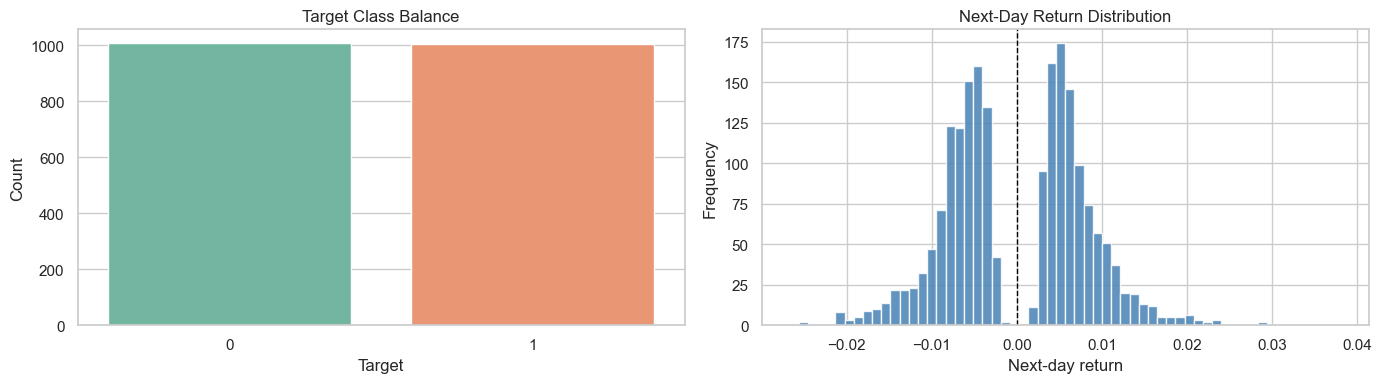

In [5]:

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.countplot(x='target', data=label_df, ax=axes[0], palette='Set2')
axes[0].set_title('Target Class Balance')
axes[0].set_xlabel('Target')
axes[0].set_ylabel('Count')

axes[1].hist(label_df['next_day_return'], bins=60, color='steelblue', alpha=0.85)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set_title('Next-Day Return Distribution')
axes[1].set_xlabel('Next-day return')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.savefig(FIG_DIR / 'draft_target_distribution.png', dpi=150)
plt.show()



### EDA Summary

The label distribution is nearly balanced after removing neutral days, which is helpful for comparing classifiers without severe class imbalance distortion. The raw dataset itself has no missing values, but rolling calculations naturally create startup nulls that must be removed before modeling.

The target design matters here because daily FX moves are often very small. Using an ATR-based threshold focuses the classification problem on moves that are more likely to be meaningful rather than random day-to-day noise.



## 2. Feature Engineering

I created several leakage-safe features using only information available before the prediction day. The three primary custom features highlighted for the draft requirement are:

1. **`momentum_5`**: five-day price momentum, calculated as the prior close divided by the close from five trading days earlier minus one. This captures short-term directional persistence or reversal.
2. **`sma_ratio_5_10`**: the ratio between the 5-day and 10-day moving averages, shifted so it only uses prior data. This approximates short-term trend structure and whether price is above or below its recent baseline.
3. **`atr_pct_14`**: 14-day average true range scaled by prior close. This captures the recent volatility regime, which is important in FX because the same raw move can be meaningful in calm markets and insignificant in volatile markets.

I also include `return_1d` and `range_pct` as supporting draft features because very recent return behavior and daily intraday range often help contextualize short-horizon price movement.


In [6]:

# All engineered features are shifted where needed so they only use prior information.
df['return_1d'] = df['close'].pct_change().shift(1)
df['range_pct'] = ((df['high'] - df['low']) / df['close']).shift(1)
df['momentum_5'] = (df['close'].shift(1) / df['close'].shift(6)) - 1

df['sma_5'] = df['close'].rolling(5).mean().shift(1)
df['sma_10'] = df['close'].rolling(10).mean().shift(1)
df['sma_ratio_5_10'] = (df['sma_5'] / df['sma_10']) - 1

feature_cols = ['return_1d', 'range_pct', 'momentum_5', 'sma_ratio_5_10', 'atr_pct_14']
model_df = df[['timestamp'] + feature_cols + ['target']].dropna().copy()
model_df['target'] = model_df['target'].astype(int)

print(f'Rows available for modeling: {len(model_df):,}')
display(model_df.head())


Rows available for modeling: 2,012


,timestamp,return_1d,range_pct,momentum_5,sma_ratio_5_10,atr_pct_14,target
14,2007-02-05,-0.004608,0.008718,0.003562,0.001156,0.005996,1
18,2007-02-09,0.002152,0.005061,0.001459,0.000223,0.005719,0
19,2007-02-12,-0.002684,0.004767,0.003395,0.000208,0.005778,1
20,2007-02-13,-0.002999,0.007404,0.002939,0.000724,0.005691,1
27,2007-02-22,0.000152,0.004110,0.000762,0.004057,0.005436,1


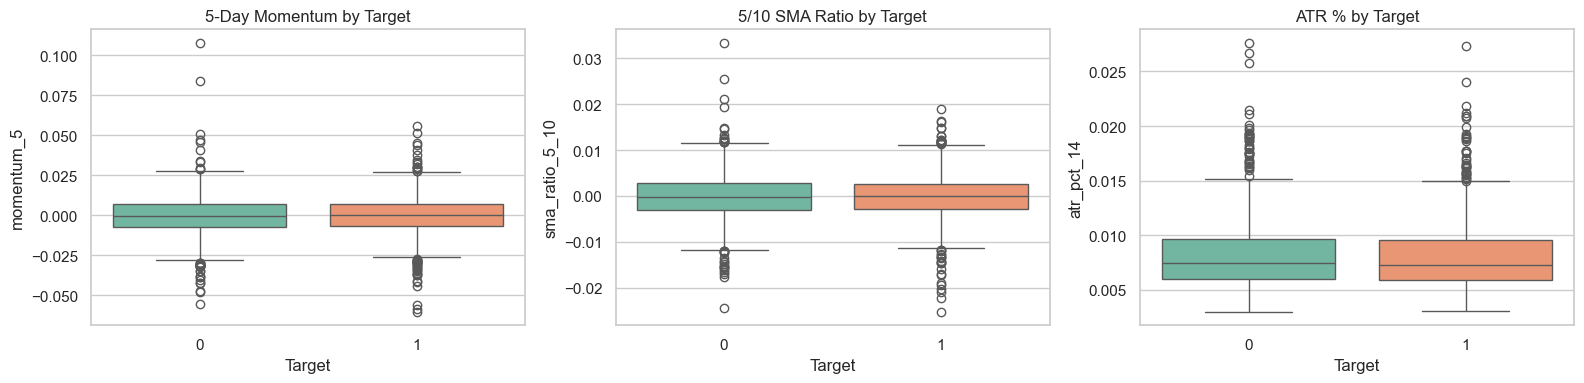

In [7]:

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
plot_features = ['momentum_5', 'sma_ratio_5_10', 'atr_pct_14']
plot_titles = ['5-Day Momentum by Target', '5/10 SMA Ratio by Target', 'ATR % by Target']

for ax, feature, title in zip(axes, plot_features, plot_titles):
    sns.boxplot(data=model_df, x='target', y=feature, ax=ax, palette='Set2')
    ax.set_title(title)
    ax.set_xlabel('Target')

plt.tight_layout()
plt.savefig(FIG_DIR / 'draft_feature_vs_target_boxplots.png', dpi=150)
plt.show()


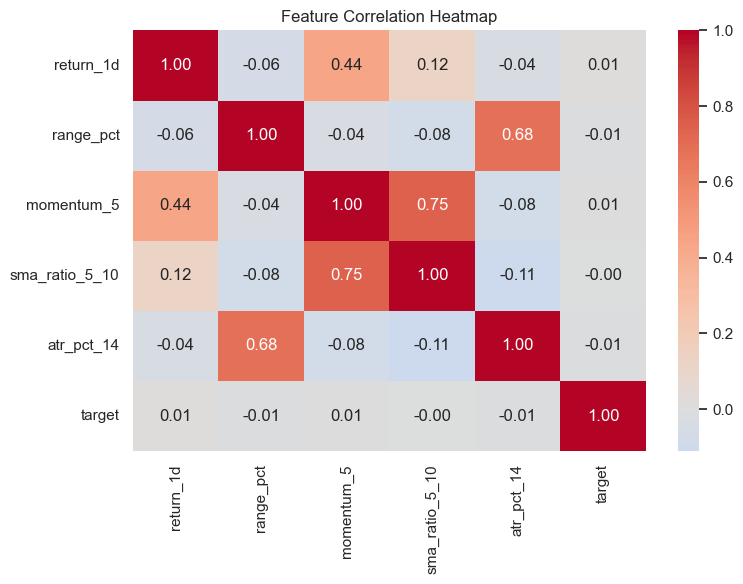

In [8]:

fig, ax = plt.subplots(figsize=(8, 6))
correlation_df = model_df[feature_cols + ['target']].corr()
sns.heatmap(correlation_df, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title('Feature Correlation Heatmap')
plt.tight_layout()
plt.savefig(FIG_DIR / 'draft_feature_correlation_heatmap.png', dpi=150)
plt.show()



## 3. Data Preparation

I use an 80/20 chronological split rather than a randomized split because the data is sequential and a random shuffle would leak future market structure into training. I do **not** use stratification for the same reason.

The raw CSV has no missing values. However, the rolling features and ATR label create initial null rows because they require historical lookback windows. Those rows are dropped before modeling, which is appropriate because they do not have enough prior context to form a valid prediction record.

For scaling, I standardize the Logistic Regression inputs using the training-set mean and standard deviation only. Random Forest is tree-based and does not require scaling, so it is trained on the original feature magnitudes.


In [9]:

split_idx = int(len(model_df) * 0.8)
train_df = model_df.iloc[:split_idx].copy()
test_df = model_df.iloc[split_idx:].copy()

X_train = train_df[feature_cols].to_numpy()
X_test = test_df[feature_cols].to_numpy()
y_train = train_df['target'].to_numpy()
y_test = test_df['target'].to_numpy()

train_means = X_train.mean(axis=0)
train_stds = X_train.std(axis=0)
train_stds[train_stds == 0] = 1

X_train_scaled = (X_train - train_means) / train_stds
X_test_scaled = (X_test - train_means) / train_stds

print(f'Train rows: {len(train_df):,}')
print(f'Test rows: {len(test_df):,}')
print(f'Train period: {train_df["timestamp"].min().date()} to {train_df["timestamp"].max().date()}')
print(f'Test period: {test_df["timestamp"].min().date()} to {test_df["timestamp"].max().date()}')


Train rows: 1,609
Test rows: 403
Train period: 2007-02-05 to 2022-05-17
Test period: 2022-05-18 to 2026-03-13



## 4. Model 1: Logistic Regression

Logistic Regression serves as the interpretable baseline. I keep the hyperparameters simple and use `liblinear` for stable binary classification. This model helps show whether a linear decision boundary is enough for the engineered FX features.


In [10]:

log_reg = LogisticRegression(
    solver='liblinear',
    max_iter=1000,
    random_state=42,
)

start = time.perf_counter()
log_reg.fit(X_train_scaled, y_train)
log_reg_train_time = time.perf_counter() - start

log_reg_preds = log_reg.predict(X_test_scaled)

log_reg_metrics = {
    'Model': 'Logistic Regression',
    'Hyperparameters': 'solver=liblinear, max_iter=1000',
    'Accuracy': accuracy_score(y_test, log_reg_preds),
    'Precision': precision_score(y_test, log_reg_preds, zero_division=0),
    'Recall': recall_score(y_test, log_reg_preds, zero_division=0),
    'F1': f1_score(y_test, log_reg_preds, zero_division=0),
    'Train Time (sec)': log_reg_train_time,
}

pd.DataFrame([log_reg_metrics])


,Model,Hyperparameters,Accuracy,Precision,Recall,F1,Train Time (sec)
0,Logistic Regression,"solver=liblinear, max_iter=1000",0.488834,0.500000,0.500000,0.500000,0.003690



## 5. Model 2: Random Forest

Random Forest is the nonlinear model. It is useful here because FX relationships may depend on interactions between momentum, range, and volatility features that a linear classifier cannot capture directly.


In [11]:

random_forest = RandomForestClassifier(
    n_estimators=200,
    max_depth=6,
    min_samples_leaf=10,
    n_jobs=1,
    random_state=42,
)

start = time.perf_counter()
random_forest.fit(X_train, y_train)
rf_train_time = time.perf_counter() - start

rf_preds = random_forest.predict(X_test)

rf_metrics = {
    'Model': 'Random Forest',
    'Hyperparameters': 'n_estimators=200, max_depth=6, min_samples_leaf=10',
    'Accuracy': accuracy_score(y_test, rf_preds),
    'Precision': precision_score(y_test, rf_preds, zero_division=0),
    'Recall': recall_score(y_test, rf_preds, zero_division=0),
    'F1': f1_score(y_test, rf_preds, zero_division=0),
    'Train Time (sec)': rf_train_time,
}

pd.DataFrame([rf_metrics])


,Model,Hyperparameters,Accuracy,Precision,Recall,F1,Train Time (sec)
0,Random Forest,"n_estimators=200, max_depth=6, min_samples_lea...",0.493797,0.503846,0.635922,0.562232,0.269837



## 6. Training And Validation Visualizations

To visualize overfitting behavior, I track Random Forest training and test accuracy across several tree depths. This is not a full hyperparameter search, but it gives a useful early signal about whether additional complexity is helping or simply memorizing the training set.


,max_depth,train_accuracy,test_accuracy
0,2,0.571162,0.486352
1,3,0.604102,0.483871
2,4,0.649472,0.486352
3,5,0.670603,0.488834
4,6,0.732132,0.493797
5,8,0.784338,0.501241
6,10,0.817278,0.516129
7,None,0.863269,0.508685


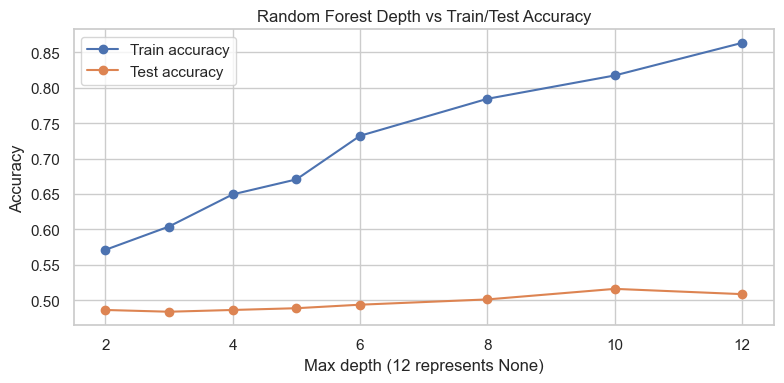

In [12]:

depths = [2, 3, 4, 5, 6, 8, 10, None]
validation_rows = []

for depth in depths:
    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=depth,
        min_samples_leaf=10,
        n_jobs=1,
        random_state=42,
    )
    model.fit(X_train, y_train)
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    validation_rows.append({
        'max_depth': 'None' if depth is None else depth,
        'train_accuracy': accuracy_score(y_train, train_pred),
        'test_accuracy': accuracy_score(y_test, test_pred),
    })

validation_df = pd.DataFrame(validation_rows)
display(validation_df)

fig, ax = plt.subplots(figsize=(8, 4))
plot_x = [12 if value == 'None' else value for value in validation_df['max_depth']]
ax.plot(plot_x, validation_df['train_accuracy'], marker='o', label='Train accuracy')
ax.plot(plot_x, validation_df['test_accuracy'], marker='o', label='Test accuracy')
ax.set_title('Random Forest Depth vs Train/Test Accuracy')
ax.set_xlabel('Max depth (12 represents None)')
ax.set_ylabel('Accuracy')
ax.legend()
plt.tight_layout()
plt.savefig(FIG_DIR / 'draft_rf_validation_curve.png', dpi=150)
plt.show()


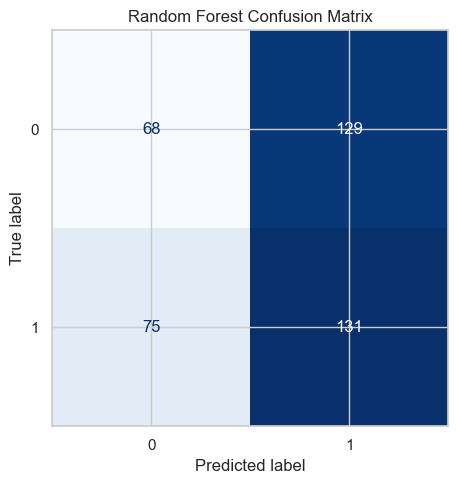

In [13]:

fig, ax = plt.subplots(figsize=(5, 5))
ConfusionMatrixDisplay.from_predictions(y_test, rf_preds, ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Random Forest Confusion Matrix')
plt.tight_layout()
plt.savefig(FIG_DIR / 'draft_rf_confusion_matrix.png', dpi=150)
plt.show()



## 7. Model Comparison


In [14]:

comparison_df = pd.DataFrame([log_reg_metrics, rf_metrics])
comparison_df['Accuracy'] = comparison_df['Accuracy'].round(3)
comparison_df['Precision'] = comparison_df['Precision'].round(3)
comparison_df['Recall'] = comparison_df['Recall'].round(3)
comparison_df['F1'] = comparison_df['F1'].round(3)
comparison_df['Train Time (sec)'] = comparison_df['Train Time (sec)'].round(4)
comparison_df


,Model,Hyperparameters,Accuracy,Precision,Recall,F1,Train Time (sec)
0,Logistic Regression,"solver=liblinear, max_iter=1000",0.489000,0.500000,0.500000,0.500000,0.003700
1,Random Forest,"n_estimators=200, max_depth=6, min_samples_lea...",0.494000,0.504000,0.636000,0.562000,0.269800



Random Forest performs better in this draft because it captures more of the positive class and achieves the strongest F1 score, even though the accuracy difference is small. That result suggests the relationship between recent FX momentum, range, and volatility is not fully linear.

The main trade-off is interpretability versus flexibility. Logistic Regression is easier to explain and faster to train, while Random Forest better handles nonlinear interactions but is harder to interpret directly and still shows only modest overall accuracy.

At this stage, I am leaning toward Random Forest for the final submission because it delivers the best balance of recall and F1. However, I would keep Logistic Regression in the project as a transparent benchmark so improvements from later feature engineering are easier to judge.



## 8. Next Steps And Reflection

For the final submission, I plan to expand the feature set beyond the current draft features. The next additions would likely include longer-horizon momentum windows, rolling volatility change, candle-body direction and size, and regime features that compare short-term versus long-term trend state. Those additions should help test whether the current weak signal is caused by limited information rather than poor model choice.

For model optimization, I would tune the Random Forest hyperparameters more systematically, experiment with the ATR threshold used to define the target, and evaluate whether alternative labeling rules produce a cleaner signal. I would also test a small time-series cross-validation setup so the final model choice is not based on a single holdout period.

The main question I would ask my instructor is whether this volatility-filtered binary target is the right level of ambition for the course project or whether a simpler up/down label would be more appropriate for the final version. I would also like feedback on whether my emphasis on leakage prevention and chronological evaluation is enough, or whether I should add more explicit discussion of time-series validation methodology in the final submission.
